# Bank Term Deposit Subscription Prediction

This notebook implements three methods to predict whether a client will subscribe to a term deposit based on the Bank Marketing dataset.

**Methods:**
1.  **Classification:** Decision Tree Classifier
2.  **Linear Regression:** Linear Probability Model (Threshold = 0.5)
3.  **Random Forest:** Random Forest Classifier

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

sns.set(style="whitegrid")

## 1. Load Data

In [30]:
file_path = 'dataset/bank-additional-full.csv'
data_raw = pd.read_csv(file_path, sep=';')

data_strategy2 = data_raw.copy()
data = data_raw.copy()

print(data.head())
print(f"Total rows in dataset: {len(data)}")

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

## 1.1 Data Cleaning (Strategy 1: Imputation)

- **Duplicates**: Remove duplicate rows.
- **Missing Values**: Replace 'unknown' with `NaN` and impute with **Mode** (Most Frequent).
- **Note**: This strategy assumes 'unknown' is simply missing data to be filled.

In [31]:
duplicates = data.duplicated().sum()
if duplicates > 0:
    data = data.drop_duplicates()

data.replace('unknown', np.nan, inplace=True)

categorical_cols = data.select_dtypes(include=['object']).columns
imputer = SimpleImputer(strategy='most_frequent')
data[categorical_cols] = imputer.fit_transform(data[categorical_cols])

print("Strategy 1: Imputation Completed.")

Strategy 1: Imputation Completed.


In [32]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  object 
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null  floa

## 2. Preprocessing (Strategy 1)

- Encode categorical variables using One-Hot Encoding.
- Encode target variable `y` using Label Encoding.

In [33]:
le = LabelEncoder()
data['y'] = le.fit_transform(data['y'])

categorical_cols = data.select_dtypes(include=['object']).columns

data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

print(f"New shape: {data_encoded.shape}")

New shape: (41176, 48)


## 3. Train/Test Split (Strategy 1)

In [34]:
X = data_encoded.drop('y', axis=1)
y = data_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size (80%): {X_train.shape[0]}")
print(f"Test set size (20%): {X_test.shape[0]}")

Training set size (80%): 32940
Test set size (20%): 8236


## 4. Model Implementation (Strategy 1)

### Method 1: Classification (Decision Tree)

In [35]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

acc_dt_1 = accuracy_score(y_test, y_pred_dt)
print("---- Decision Tree Results (Strategy 1) ----")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

---- Decision Tree Results (Strategy 1) ----
Accuracy: 0.8853812530354541

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.94      7265
           1       0.51      0.51      0.51       971

    accuracy                           0.89      8236
   macro avg       0.72      0.72      0.72      8236
weighted avg       0.89      0.89      0.89      8236



### Method 2: Linear Regression
Since Linear Regression gives continuous output, we threshold at 0.5 to classify as 0 or 1.

In [36]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr_raw = lr_model.predict(X_test)

y_pred_lr = (y_pred_lr_raw >= 0.5).astype(int)

acc_lr_1 = accuracy_score(y_test, y_pred_lr)
print("---- Linear Regression Results (Strategy 1) ----")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr_raw))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

---- Linear Regression Results (Strategy 1) ----
Accuracy: 0.9015298688683827
R2 Score: 0.34527211974763206

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.95      7265
           1       0.68      0.32      0.43       971

    accuracy                           0.90      8236
   macro avg       0.80      0.65      0.69      8236
weighted avg       0.89      0.90      0.89      8236



### Method 3: Random Forest

In [37]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

acc_rf_1 = accuracy_score(y_test, y_pred_rf)
print("---- Random Forest Results (Strategy 1) ----")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

---- Random Forest Results (Strategy 1) ----
Accuracy: 0.9099077221952404

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      7265
           1       0.68      0.45      0.54       971

    accuracy                           0.91      8236
   macro avg       0.80      0.71      0.75      8236
weighted avg       0.90      0.91      0.90      8236



## 5. Comparison of Models (Strategy 1)

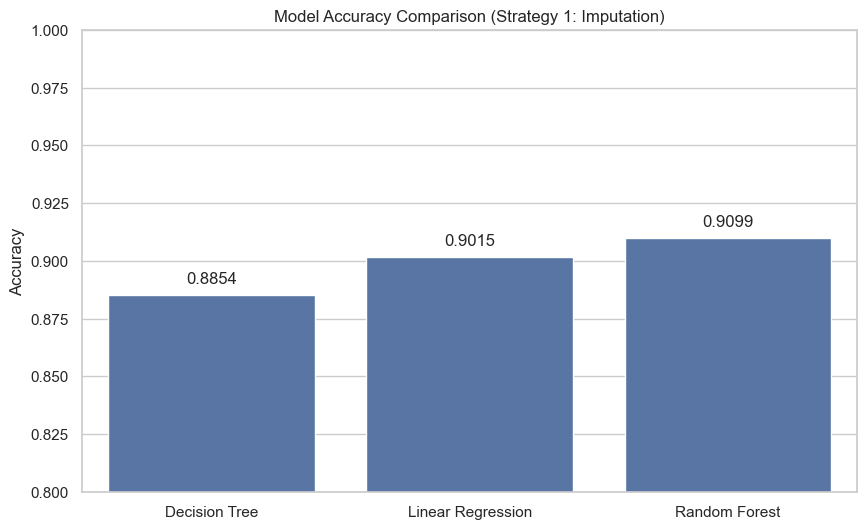

In [38]:
models = ['Decision Tree', 'Linear Regression', 'Random Forest']
accuracies_s1 = [acc_dt_1, acc_lr_1, acc_rf_1]

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies_s1)
plt.title('Model Accuracy Comparison (Strategy 1: Imputation)')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
for i, v in enumerate(accuracies_s1):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center')
plt.show()

## 6. Advanced Analysis: Strategy 2 (Unknown as Category)

In this strategy, we handle the high number of 'unknown' values (especially in `default`) by treating them as a separate category, rather than imputing them.

In [39]:
duplicates = data_strategy2.duplicated().sum()
if duplicates > 0:
    data_strategy2 = data_strategy2.drop_duplicates()

print("Strategy 2: Keeping 'unknown' as category.")

le = LabelEncoder()
data_strategy2['y'] = le.fit_transform(data_strategy2['y'])

categorical_cols = data_strategy2.select_dtypes(include=['object']).columns
data_encoded_s2 = pd.get_dummies(data_strategy2, columns=categorical_cols, drop_first=True)

print(f"New shape (Strategy 2): {data_encoded_s2.shape}")

X2 = data_encoded_s2.drop('y', axis=1)
y2 = data_encoded_s2['y']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

dt_model2 = DecisionTreeClassifier(random_state=42)
dt_model2.fit(X_train2, y_train2)
acc_dt_2 = accuracy_score(y_test2, dt_model2.predict(X_test2))

lr_model2 = LinearRegression()
lr_model2.fit(X_train2, y_train2)
y_pred_lr2 = (lr_model2.predict(X_test2) >= 0.5).astype(int)
acc_lr_2 = accuracy_score(y_test2, y_pred_lr2)

rf_model2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model2.fit(X_train2, y_train2)
acc_rf_2 = accuracy_score(y_test2, rf_model2.predict(X_test2))

print("Strategy 2 Results:")
print(f"Decision Tree: {acc_dt_2}")
print(f"Linear Regression: {acc_lr_2}")
print(f"Random Forest: {acc_rf_2}")

Strategy 2: Keeping 'unknown' as category.
New shape (Strategy 2): (41176, 54)
Strategy 2 Results:
Decision Tree: 0.8887809616318602
Linear Regression: 0.901287032540068
Random Forest: 0.9090577950461389


## 7. Performance Comparison: Strategy 1 vs Strategy 2

We compare the accuracy of all three models under both strategies.

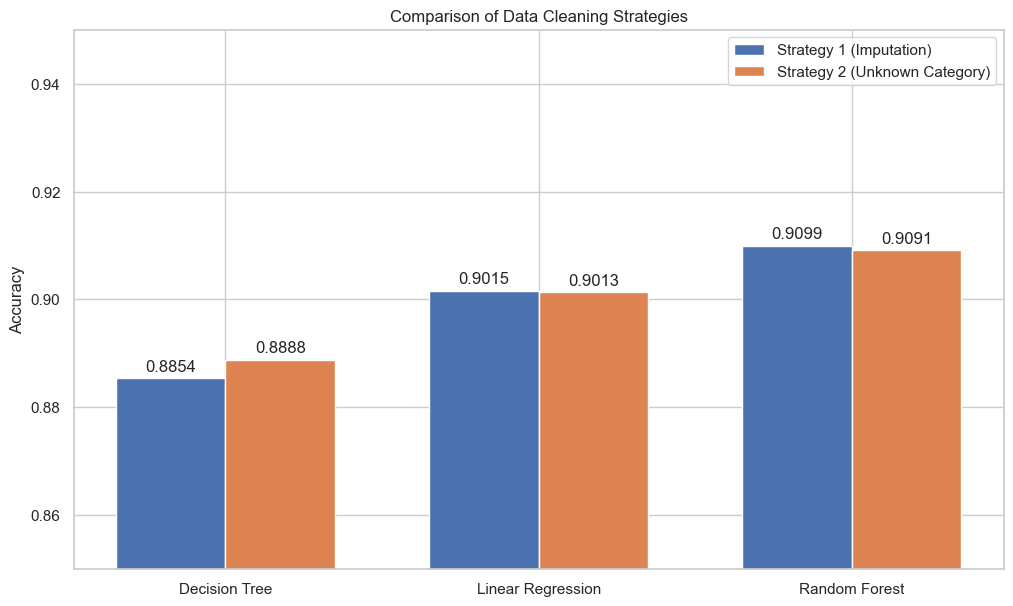

In [40]:
labels = ['Decision Tree', 'Linear Regression', 'Random Forest']
s1_scores = [acc_dt_1, acc_lr_1, acc_rf_1]
s2_scores = [acc_dt_2, acc_lr_2, acc_rf_2]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12, 7))
rects1 = plt.bar(x - width/2, s1_scores, width, label='Strategy 1 (Imputation)')
rects2 = plt.bar(x + width/2, s2_scores, width, label='Strategy 2 (Unknown Category)')

plt.ylabel('Accuracy')
plt.title('Comparison of Data Cleaning Strategies')
plt.xticks(x, labels)
plt.ylim(0.85, 0.95)
plt.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.show()